Running AlievPanfilovElems:  99%|█████████▉| 99/100 [00:00<00:00, 649.94it/s]


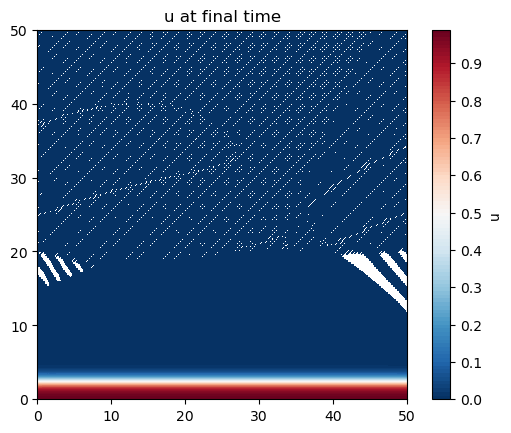

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import finitewave as fw


def build_triangular_mesh(n, m, x_range=(0, 1), y_range=(0, 1)):
    x = np.linspace(x_range[0], x_range[1], n+1)
    y = np.linspace(y_range[0], y_range[1], m+1)
    xv, yv = np.meshgrid(x, y)
    coords = np.vstack([xv.ravel(), yv.ravel(), np.zeros((n+1)*(m+1))]).T

    elems = []
    for j in range(m):
        for i in range(n):
            v0 = j * (n + 1) + i
            v1 = v0 + 1
            v2 = v0 + (n + 1)
            v3 = v2 + 1
            elems.append([v0, v1, v3])
            elems.append([v0, v3, v2])
    elems = np.array(elems)

    return coords, elems


# create a tissue of size 400x400 with cardiomycytes:
n = 200
size = 50

coords, elems = build_triangular_mesh(n, n, (0, size), (0, size))

tissue = fw.CardiacTissueElem(coords, elems)
# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoordElem(0, 1, 0, size, 0, 1))
stim_sequence.add_stim(fw.StimVoltageCoordElem(45, 1, 0, size//2, 0, size))

# create model object and set up parameters:
aliev_panfilov = fw.AlievPanfilovElems()
aliev_panfilov.dt = 0.01
aliev_panfilov.t_max = 1
# add the tissue and the stim parameters to the model object:
aliev_panfilov.cardiac_tissue = tissue
aliev_panfilov.stim_sequence = stim_sequence

# run the model:
aliev_panfilov.run(num_of_threads=1)

u = aliev_panfilov.u

# show the potential map at the end of calculations:
plt.figure()
plt.tricontourf(coords[:, 0], coords[:, 1], elems, u, levels=100,
                cmap="RdBu_r")
plt.colorbar(label='u')
plt.title('u at final time')
plt.gca().set_aspect('equal')
plt.show()

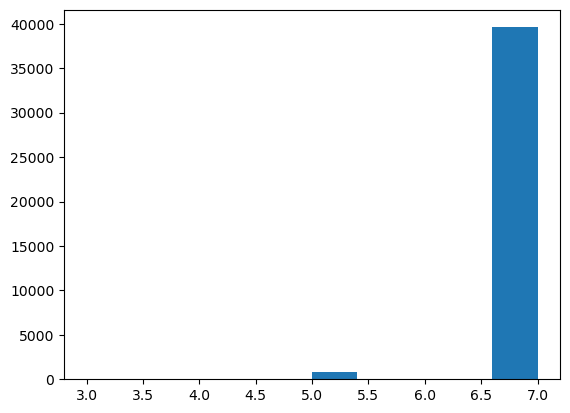

In [8]:
A, M = aliev_panfilov.weights

nnz_per_row = np.diff(A.indptr)

plt.hist(nnz_per_row)
plt.show()